1. Research and compare different configuration management tools (Ansible,
Puppet, Chef) and write a report on their use cases and advantages?

* Configuration Management Tools: Comparative Analysis ReportConfiguration Management (CM) tools automate the provisioning, tracking, and enforcement of infrastructure states. 1  Selecting the right tool depends on your organization's architecture, team skill set, and operational requirements.

 #### Ansible >
* It is agentless/ push based  architecture technology develop by IBM and configuration done in YML language. it is easy for setup  and learning.
ansible use SSH, WinRM communication protocol.
* Ansible operates on an agentless, push-based model. It uses standard protocols like SSH (for Linux) and WinRM (for Windows) to connect to target nodes, execute temporary Python modules, and cleanly exit
###### Limitation >
 * Performance can slow down at massive scale due to SSH overhead (though execution nodes in Red Hat Ansible Automation Platform help mitigate this).
Lacks native continuous state tracking—it enforces state when executed, but does not passively detect configuration drift between runs.

##### Puppet >
* It is agent bashed /pulled based architecture technology develop by puppet. we can right playbook in puppet DSL(Declarative) configuration and learning moderate. HTTPS/ SSL certificate protocol used for communication.
* Puppet relies on an agent-based, pull-based architecture. A central Puppet Server stores configuration manifests, and agents installed on managed nodes periodically "check in" (by default, every 30 minutes) to pull down updated states and correct any drift.

##### Limitation >

* Requires learning Puppet DSL, a custom declarative language with a moderate learning curve.PKI/SSL certificate management between the master and agent nodes adds operational setup complexity.


#### Chef >
*  Chef treats infrastructure strictly as code, leveraging Ruby DSL. Configurations are organized into "Recipes" within "Cookbooks." It operates primarily on an agent-based, pull-based architecture with a central Chef Server, managed client nodes, and local developer Workstations. Ruby language used for write the playbook due to this its complexity is high Maximum Flexibility & Power: Because it uses Ruby, developers can write complex loops, logic, and custom conditions that declarative languages struggle with.Compliance Testing (Chef InSpec)Industry-standard framework for auditing and testing security policies as code.

#### Limitation >

* Steep Learning Curve: Requires true programming/software development skills; system administrators without Ruby experience face a significant barrier.

#### Use Cases :
 #### Ansible
 * You need rapid deployment with minimal upfront configuration.Your team consists primarily of sysadmins, network engineers, or operators without deep programming backgrounds.You are managing network devices, edge devices, or cloud instances where installing an agent is impractical.

 #### Puppet
  * You operate in a heavily regulated industry (finance, healthcare, government) requiring strict compliance audits.You manage large enterprise server fleets and need to automatically detect and correct configuration drift.You want a mature, declarative model to enforce an exact "desired state" across your fleet.

 #### Chef
 *  Your organization is developer-heavy and comfortable    writing Ruby.
 You have highly complex, dynamic infrastructure environments requiring sophisticated programmatic logic.
 You want to integrate deep compliance testing directly into your software build pipelines via tools like Chef InSpec

2. Extend the CI pipeline to include continuous delivery using Jenkins or GitLab CI. Implement a blue-green deployment strategy?


In [ ]:
Create file

.gitlab-ci.yml # playbook


stages:
  - build
  - test
  - deploy_green
  - smoke_test
  - switch_traffic
  - rollback

variables:
  DOCKER_IMAGE: "$CI_REGISTRY_IMAGE:$CI_COMMIT_SHA"

# --- CI STAGES ---
build:
  stage: build
  script:
    - docker build -t $DOCKER_IMAGE .
    - docker push $DOCKER_IMAGE

unit_tests:
  stage: test
  script:
    - docker run --rm $DOCKER_IMAGE npm test

# --- CD STAGES ---
deploy_to_green:
  stage: deploy_green
  environment:
    name: green
    url: https://green.example.com
  script:
    - echo "Deploying new version ($CI_COMMIT_SHA) to GREEN environment..."
    - ./scripts/deploy.sh --target green --image $DOCKER_IMAGE

run_smoke_tests:
  stage: smoke_test
  script:
    - echo "Running smoke tests against Green environment..."
    - curl -f https://green.example.com/health || exit 1
    - npm run test:integration -- --url=https://green.example.com

switch_to_green:
  stage: switch_traffic
  environment:
    name: production
    url: https://example.com
  script:
    - echo "Switching primary router/load balancer to point to GREEN..."
    - ./scripts/switch-traffic.sh --to green
  when: manual # Requires manual approval to trigger live switch
  only:
    - main

rollback_to_blue:
  stage: rollback
  script:
    - echo "Emergency Rollback: Reverting traffic back to BLUE..."
    - ./scripts/switch-traffic.sh --to blue
  when: manual
  only:
    - main

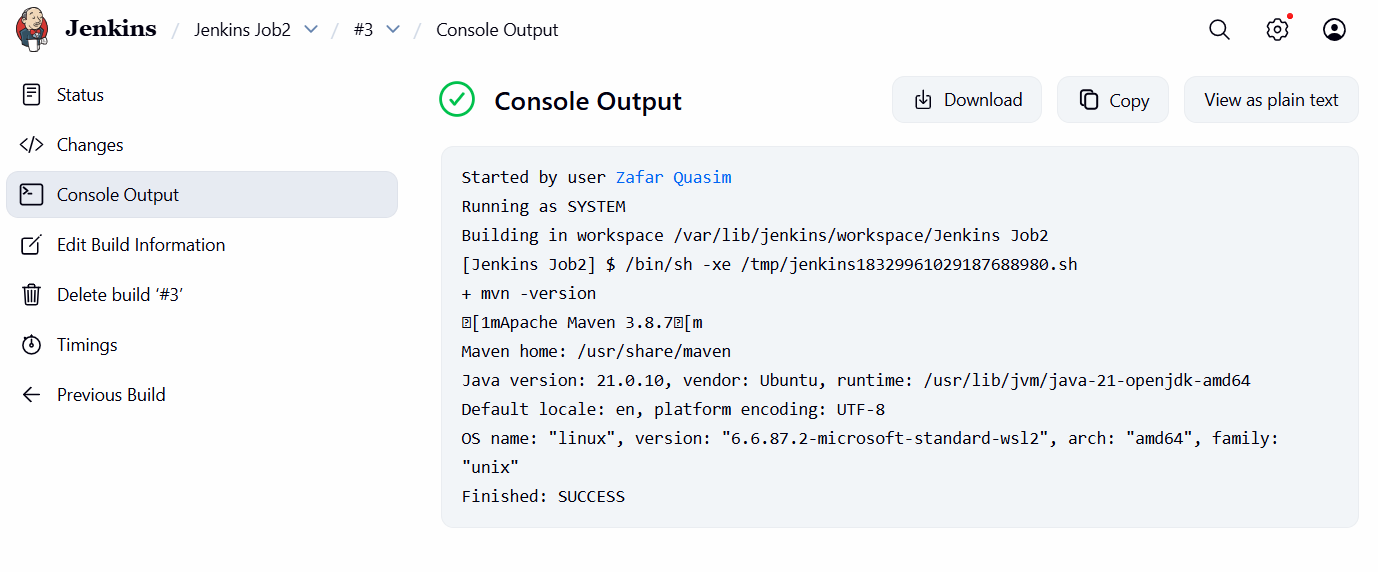